In [1]:
import os
import random
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input

2026-04-21 15:37:37.548521: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-21 15:37:37.558810: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776778657.568832   95095 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776778657.572112   95095 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776778657.580404   95095 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
!nvidia-smi

Tue Apr 21 15:37:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.45.03              Driver Version: 595.71         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        On  |   00000000:01:00.0 Off |                  N/A |
|  0%   39C    P8             27W /  390W |     341MiB /  24576MiB |      8%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Load dataset

In [4]:
def load_paths(filepath):
    lines = []
    with open(filepath, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]
    
    base_dir = os.path.dirname(filepath) + '/HR/' + lines[0]
    seq_count = len(os.listdir(base_dir))

    result = [""] * seq_count * len(lines) * 7
    print(len(result))
    for i, line in enumerate(lines):
        for j in range(seq_count):
            for k in range(7):
                index = i * seq_count * 7 + j * 7 + k
                result[index] = os.path.join(f"{line}/{j}/im{k+1}.png")
    return result

In [5]:
train_paths = load_paths('/mnt/c/Users/henrik/Downloads/vimeo90k_upscale/train.txt')
val_paths = load_paths('/mnt/c/Users/henrik/Downloads/vimeo90k_upscale/test.txt')

1356852
164304


In [6]:
def create_sr_dataset(
    root_path: str, 
    relative_paths: list[str], 
    batch_size: int = 32,
    is_training: bool = True,
    shuffle_buffer_size: int = 1000
):
    """
    Creates a lazy tf.data.Dataset for Super Resolution.
    
    Args:
        root_path: The base directory containing 'LR' and 'HR' folders.
        relative_paths: List of filenames/relative paths of the images.
        batch_size: The batch size for the dataset.
        is_training: If True, shuffles the dataset. If False, keeps original order for validation/testing.
        shuffle_buffer_size: The number of elements to maintain in the shuffle buffer.
    """
    paths_ds = tf.data.Dataset.from_tensor_slices(relative_paths)
    
    # Shuffle early in the pipeline if this is a training dataset
    if is_training:
        # Buffer size should ideally be larger than the batch size or the full dataset size
        # if memory permits, to ensure true randomness.
        paths_ds = paths_ds.shuffle(buffer_size=shuffle_buffer_size, reshuffle_each_iteration=True)
    
    def process_path(rel_path):
        # Construct the full paths by joining the root, subfolder, and relative path
        lr_path = tf.strings.join([root_path, 'LR', rel_path], separator=os.sep)
        hr_path = tf.strings.join([root_path, 'HR', rel_path], separator=os.sep)
        
        # Read the raw files (lazy loading)
        lr_img = tf.io.read_file(lr_path)
        hr_img = tf.io.read_file(hr_path)
        
        # Decode the images (adjust channels to 1 if using grayscale)
        lr_img = tf.image.decode_image(lr_img, channels=3, expand_animations=False)
        hr_img = tf.image.decode_image(hr_img, channels=3, expand_animations=False)
        
        # Convert to float32 and normalize to [0, 1] range
        lr_img = tf.cast(lr_img, tf.float32) / 255.0
        hr_img = tf.cast(hr_img, tf.float32) / 255.0
        
        return lr_img, hr_img

    # Use map to lazily load and transform the images automatically
    dataset = paths_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Batch the dataset
    dataset = dataset.batch(batch_size, drop_remainder=is_training)
    
    # Prefetch data to the GPU/Accelerator to prevent I/O bottlenecks
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return dataset

In [7]:

root_dir = "/mnt/c/Users/henrik/Downloads/vimeo90k_upscale/"
train_files = random.sample(train_paths, int(len(train_paths) * 0.05))
val_files = random.sample(val_paths, int(len(val_paths) * 0.05))

# Training dataset (Shuffled and drops incomplete batches)
train_ds = create_sr_dataset(root_dir, train_files, batch_size=32, is_training=True)
# 
# # Validation dataset (Not shuffled, keeps all data)
val_ds = create_sr_dataset(root_dir, val_files, batch_size=32, is_training=False)

I0000 00:00:1776778673.785891   95095 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21764 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


## Dummy model

In [23]:

def create_dummy_model(x_width, x_height, y_width, y_height, interpolation="bilinear"):
    inp = tf.keras.layers.Input(shape=(x_height, x_width, 3))
    out = tf.keras.layers.Resizing(y_height, y_width, interpolation=interpolation)(inp)
    model = tf.keras.Model(inputs=inp, outputs=out)
    return model
dummy_model = create_dummy_model(32, 32, 64, 64)

# 2. Define a custom metric for PSNR
def psnr_metric(y_true, y_pred):
    # Calculate PSNR manually to avoid Keras graph-mode Assert issues in tf.image.psnr
    # We add a small epsilon (1e-10) to the MSE to prevent the result from becoming 'inf'
    mse = tf.reduce_mean(tf.square(y_true - y_pred), axis=[1, 2, 3])
    # PSNR = 10 * log10(max_val^2 / MSE). Here max_val is 1.0.
    # tf.math.log is natural log, so we divide by log(10) to get log10.
    return 10.0 * (tf.math.log(1.0 / (mse + 1e-10)) / tf.math.log(10.0))

# 3. Compile the model with MSE loss and our PSNR metric
dummy_model.compile(
    optimizer='adam', # Optimizer isn't actually used since no weights, but required for compile
    loss='mse',
    metrics=[psnr_metric]
)


In [24]:
dummy_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_5 (Resizing)           │ (None, 64, 64, 3)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
print("Evaluating linear upscaling dummy model on the entire validation dataset...")

# 4. Use Keras built-in .evaluate() on the validation dataset (val_ds)
evaluation_results = dummy_model.evaluate(val_ds)

print("-" * 30)
print(f"Validation Mean Squared Error (Loss): {evaluation_results[0]:.4f}")
print(f"Validation Mean PSNR:                 {evaluation_results[1]:.2f} dB")

Evaluating linear upscaling dummy model on the entire validation dataset...


I0000 00:00:1776778682.996957   95248 service.cc:152] XLA service 0x796588003d90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776778682.996997   95248 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
I0000 00:00:1776778683.012267   95248 cuda_dnn.cc:529] Loaded cuDNN version 92000


 10/257 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0026 - psnr_metric: 30.1562 

I0000 00:00:1776778683.238637   95248 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


257/257 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.0026 - psnr_metric: 29.3909
------------------------------
Validation Mean Squared Error (Loss): 0.0026
Validation Mean PSNR:                 29.39 dB


In [25]:
dummy_model.save('upscale_dummy.keras')

## Upscaler

- 29.5 db is the linear upscale, need to beat

In [14]:
def create_upscaler(input_shape=(32, 32, 3), scale_factor=2):
    """
    Creates a larger image upscaling neural network (under 1MB).
    
    Args:
        input_shape: Shape of the input image (height, width, channels). 
                     (None, None, 3) allows for dynamic image sizes.
        scale_factor: Integer defining how much to upscale the image (e.g., 2, 3, 4).
                     
    Returns:
        A compiled Keras model.
    """
    inputs = layers.Input(shape=input_shape)
    
    # Feature extraction (more filters, deeper network)
    x = layers.Conv2D(64, (5, 5), activation='relu', padding='same')(inputs)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    
    # Spatial Upsampling
    x = layers.Resizing(64, 64, interpolation='bilinear')(x)
    
    # Post-upsampling refinement
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    
    # Image reconstruction
    channels = input_shape[-1] if len(input_shape) == 3 and input_shape[-1] is not None else 3
    outputs = layers.Conv2D(channels, (3, 3), activation='linear', padding='same')(x)
    
    model = models.Model(
        inputs=inputs, 
        outputs=outputs, 
        name=f'upscaler_{scale_factor}x'
    )
    
    return model

model = create_upscaler(input_shape=(32, 32, 3), scale_factor=2)
model.summary()

Model: "upscaler_2x"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_3 (Resizing)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,379 (458.51 KB)

 Trainable params: 117,379 (458.51 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[psnr_metric]
)

# 1. Ensure the checkpoint directory exists
checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "best_sr_model.keras")

# 2. Define the Callbacks
callbacks = [
    # Save the model whenever validation PSNR improves
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_psnr_metric", # We monitor our custom metric from compile()
        mode="max",                # We want maximum PSNR
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    
    # Reduce learning rate if validation loss stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,       # Halve the learning rate
        patience=3,       # Wait 3 epochs before reducing
        min_lr=1e-6,      # Minimum learning rate lower bound
        verbose=1
    ),
    
    # Stop training early if validation loss hasn't improved for a long time
    EarlyStopping(
        monitor="val_loss",
        patience=7,                      # Wait 10 epochs before stopping
        restore_best_weights=True,        # Automatically revert to the best epoch
        verbose=1
    )
]



print("Starting training...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=400,
    callbacks=callbacks
)

Starting training...
Epoch 1/400


2026-04-21 15:38:54.609234: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


2119/2120 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0050 - psnr_metric: 28.2119
Epoch 1: val_psnr_metric improved from None to 28.56944, saving model to ./checkpoints/best_sr_model.keras

Epoch 1: finished saving model to ./checkpoints/best_sr_model.keras
2120/2120 ━━━━━━━━━━━━━━━━━━━━ 78s 35ms/step - loss: 0.0027 - psnr_metric: 29.3232 - val_loss: 0.0027 - val_psnr_metric: 28.5694 - learning_rate: 0.0010
Epoch 2/400
2119/2120 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0022 - psnr_metric: 29.9097
Epoch 2: val_psnr_metric improved from 28.56944 to 29.48962, saving model to ./checkpoints/best_sr_model.keras

Epoch 2: finished saving model to ./checkpoints/best_sr_model.keras
2120/2120 ━━━━━━━━━━━━━━━━━━━━ 52s 25ms/step - loss: 0.0022 - psnr_metric: 29.9923 - val_loss: 0.0024 - val_psnr_metric: 29.4896 - learning_rate: 0.0010
Epoch 3/400
2120/2120 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0022 - psnr_metric: 29.9019
Epoch 3: val_psnr_metric improved from 29.48962 to 29.56188, saving 

KeyboardInterrupt: 

In [16]:
model.save("upscale_1.keras")

In [ ]:
tf.keras.models.load_model(
    'upscale_1.keras',
    custom_objects={'psnr_metric': psnr_metric}
)


<Functional name=functional, built=True>

## Larger network

In [13]:
def create_larger_upscaler(input_shape=(32, 32, 3), scale_factor=2):
    """
    Creates a larger image upscaling neural network.
    """
    inputs = layers.Input(shape=input_shape)
    
    # Add L2 weight regularization to prevent exploding gradients/high errors
    reg = tf.keras.regularizers.l2(1e-4)
    
    # Feature extraction
    x = layers.Conv2D(64, (5, 5), padding='same', kernel_regularizer=reg)(inputs)
    x = layers.PReLU(shared_axes=[1, 2])(x)
    
    # Residual blocks to make it deeper
    for _ in range(5):
        res = x
        x = layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=reg)(x)
        x = layers.PReLU(shared_axes=[1, 2])(x)
        x = layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=reg)(x)
        x = layers.Add()([x, res])
    
    # Spatial Upsampling
    x = layers.Conv2D(64 * (scale_factor ** 2), (3, 3), padding='same', kernel_regularizer=reg)(x)
    #x = layers.Resizing(input_shape[0] * scale_factor, input_shape[1] * scale_factor, interpolation='bilinear')(x)
    x = layers.Lambda(lambda val: tf.nn.depth_to_space(val, scale_factor))(x)

    x = layers.PReLU(shared_axes=[1, 2])(x)
    
    # Post-upsampling refinement
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=reg)(x)
    x = layers.PReLU(shared_axes=[1, 2])(x)
    
    # Image reconstruction
    channels = input_shape[-1] if len(input_shape) == 3 and input_shape[-1] is not None else 3
    outputs = layers.Conv2D(channels, (3, 3), activation='linear', padding='same')(x)
    
    model = models.Model(
        inputs=inputs, 
        outputs=outputs, 
        name=f'larger_upscaler_{scale_factor}x'
    )
    
    return model

larger_model = create_larger_upscaler(input_shape=(32, 32, 3), scale_factor=2)
larger_model.summary()


Model: "larger_upscaler_2x"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 32, 32,    │      4,864 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_8 (PReLU)   │ (None, 32, 32,    │         64 │ conv2d_14[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 32, 32,    │     36,928 │ p_re_lu_8[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_9 (PReLU)   │ (None, 32, 32,    │         64 │ conv2d_15[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 32, 32,    │     36,928 │ p_re_lu_9[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 32, 32,    │          0 │ conv2d_16[0][0],  │
│                     │ 64)               │            │ p_re_lu_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 32, 32,    │     36,928 │ add_5[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_10 (PReLU)  │ (None, 32, 32,    │         64 │ conv2d_17[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 32, 32,    │     36,928 │ p_re_lu_10[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 32, 32,    │          0 │ conv2d_18[0][0],  │
│                     │ 64)               │            │ add_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 32, 32,    │     36,928 │ add_6[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_11 (PReLU)  │ (None, 32, 32,    │         64 │ conv2d_19[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │     36,928 │ p_re_lu_11[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 32, 32,    │          0 │ conv2d_20[0][0],  │
│                     │ 64)               │            │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 32, 32,    │     36,928 │ add_7[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_12 (PReLU)  │ (None, 32, 32,    │         64 │ conv2d_21[0][0] 

 Total params: 561,027 (2.14 MB)

 Trainable params: 561,027 (2.14 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
print("Starting pretraining with MSE loss only...")

# Added gradient clipping (clipnorm=1.0) to prevent the gradients from exploding
larger_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
    loss="mse",
    metrics=[psnr_metric]
)

checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
pretrain_checkpoint_path = os.path.join(checkpoint_dir, "best_larger_sr_model.keras")

pretrain_callbacks = [
    ModelCheckpoint(
        filepath=pretrain_checkpoint_path,
        monitor="val_psnr_metric",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

history_pretrain = larger_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=pretrain_callbacks
)

print("Starting fine-tuning with Perceptual Loss...")

Starting pretraining with MSE loss only...
Epoch 1/50
2119/2120 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0616 - psnr_metric: 26.8331
Epoch 1: val_psnr_metric improved from None to 28.63084, saving model to ./checkpoints/best_larger_sr_model.keras

Epoch 1: finished saving model to ./checkpoints/best_larger_sr_model.keras
2120/2120 ━━━━━━━━━━━━━━━━━━━━ 59s 25ms/step - loss: 0.0433 - psnr_metric: 28.4254 - val_loss: 0.0243 - val_psnr_metric: 28.6308 - learning_rate: 1.0000e-04
Epoch 2/50
2119/2120 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0197 - psnr_metric: 29.4111
Epoch 2: val_psnr_metric improved from 28.63084 to 28.68542, saving model to ./checkpoints/best_larger_sr_model.keras

Epoch 2: finished saving model to ./checkpoints/best_larger_sr_model.keras
2120/2120 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - loss: 0.0163 - psnr_metric: 29.4424 - val_loss: 0.0113 - val_psnr_metric: 28.6854 - learning_rate: 1.0000e-04
Epoch 3/50
2118/2120 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0093 - p

KeyboardInterrupt: 

In [17]:
# Create VGG model for perceptual loss
vgg = VGG19(include_top=False, weights='imagenet', input_shape=(None, None, 3))
vgg.trainable = False
# Use an earlier layer to extract features without going through the whole VGG
loss_model = models.Model(inputs=vgg.input, outputs=vgg.get_layer('block2_conv2').output)

def perceptual_loss(y_true, y_pred):
    # Scale from [0, 1] up to [0, 255] for VGG preprocessing
    y_true_scaled = y_true * 255.0
    y_pred_scaled = y_pred * 255.0
    
    # Preprocess (center pixel vals and convert RGB -> BGR)
    y_true_vgg = preprocess_input(y_true_scaled)
    y_pred_vgg = preprocess_input(y_pred_scaled)
    
    # Extract features
    f_true = loss_model(y_true_vgg)
    f_pred = loss_model(y_pred_vgg)
    
    # MSE of features
    return tf.reduce_mean(tf.square(f_true - f_pred))

def total_loss(y_true, y_pred):
    # Combine standard MSE (L2) loss with MSE Perceptual loss
    mse_loss = tf.reduce_mean(tf.square(y_true - y_pred))
    p_loss = perceptual_loss(y_true, y_pred)
    # Reduce the weight of perceptual loss to make MSE (and therefore PSNR) more important
    return mse_loss + 0.0001 * p_loss

# Include gradient clipping here as well to stabilize fine-tuning
larger_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0), # Lower LR for fine-tuning
    loss=total_loss,
    metrics=[psnr_metric]
)

checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "best_larger_sr_model.keras")

callbacks = [
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    )
]

history_larger = larger_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=400,
    callbacks=callbacks
)

Epoch 1/400
2120/2120 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.3275 - psnr_metric: 28.5317
Epoch 1: val_loss improved from None to 1.57326, saving model to ./checkpoints/best_larger_sr_model.keras

Epoch 1: finished saving model to ./checkpoints/best_larger_sr_model.keras
2120/2120 ━━━━━━━━━━━━━━━━━━━━ 77s 34ms/step - loss: 1.3249 - psnr_metric: 28.5653 - val_loss: 1.5733 - val_psnr_metric: 28.1050 - learning_rate: 1.0000e-04
Epoch 2/400
2119/2120 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.3143 - psnr_metric: 28.5908
Epoch 2: val_loss improved from 1.57326 to 1.56427, saving model to ./checkpoints/best_larger_sr_model.keras

Epoch 2: finished saving model to ./checkpoints/best_larger_sr_model.keras
2120/2120 ━━━━━━━━━━━━━━━━━━━━ 69s 33ms/step - loss: 1.3151 - psnr_metric: 28.5924 - val_loss: 1.5643 - val_psnr_metric: 27.6966 - learning_rate: 1.0000e-04
Epoch 3/400
2119/2120 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.3085 - psnr_metric: 28.5897
Epoch 3: val_loss improved from 1.564

KeyboardInterrupt: 

In [ ]:
larger_model.save('model_upscale_2.keras')

## Visualization

In [17]:


def visualize_dataset_element(dataset, index, model=None):
    """
    Fetches an element at the given index from the dataset.
    If a model is provided, shows LR, Upscaled (with PSNR), and HR images.
    Otherwise, displays just LR and HR.
    """
    # Unbatch to access by raw element index
    unbatched = dataset.unbatch()
    
    for lr, hr in unbatched.skip(index).take(1):
        lr_np = lr.numpy()
        hr_np = hr.numpy()
        
        if model is not None:
            # Predict requires a batch dimension
            lr_batch = tf.expand_dims(lr, 0)
            pred = model(lr_batch)
            
            # Squeeze batch dimension and clip to valid image range
            pred_img = tf.clip_by_value(pred[0], 0.0, 1.0)
            
            # Calculate PSNR
            psnr = tf.image.psnr(hr, pred_img, max_val=1.0).numpy()
            
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            axes[0].imshow(lr_np)
            axes[0].set_title(f"LR Input\n{lr_np.shape}")
            axes[0].axis('off')
            
            axes[1].imshow(pred_img.numpy())
            axes[1].set_title(f"Upscaled Output\nPSNR: {psnr:.2f} dB")
            axes[1].axis('off')
            
            axes[2].imshow(hr_np)
            axes[2].set_title(f"HR Target\n{hr_np.shape}")
            axes[2].axis('off')
            
        else:
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            axes[0].imshow(lr_np)
            axes[0].set_title(f"LR Input\n{lr_np.shape}")
            axes[0].axis('off')
            
            axes[1].imshow(hr_np)
            axes[1].set_title(f"HR Target\n{hr_np.shape}")
            axes[1].axis('off')
            
        plt.tight_layout()
        plt.show()
        return

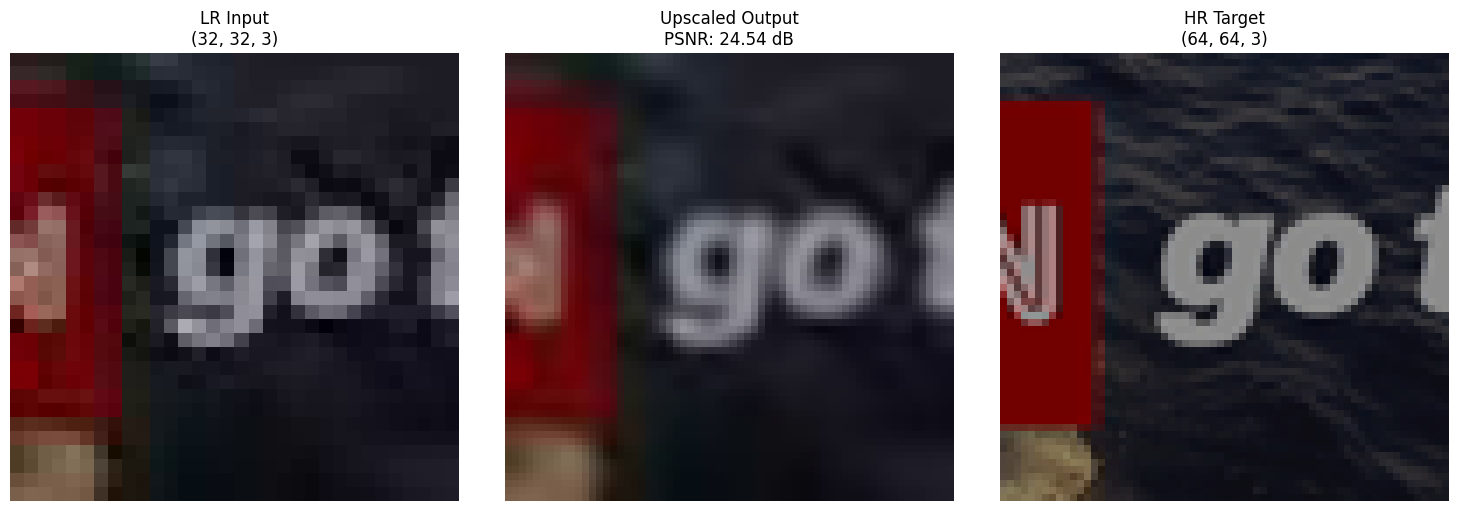

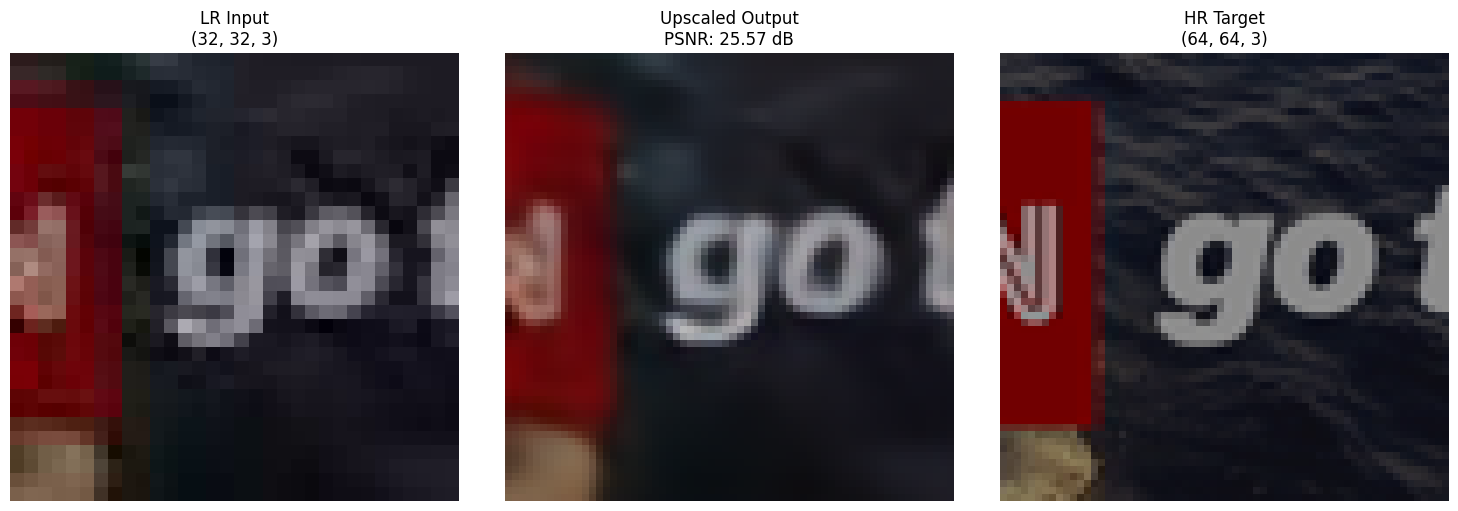

In [20]:
visualize_dataset_element(val_ds, index=988, model=dummy_model)
visualize_dataset_element(val_ds, index=988, model=model)

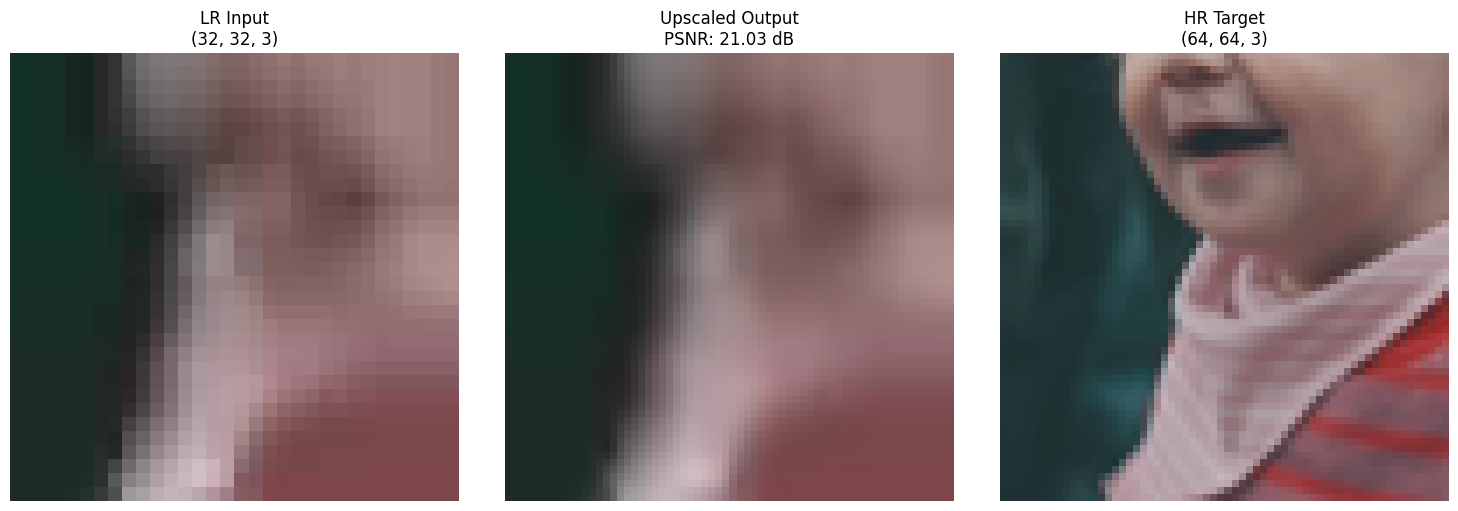

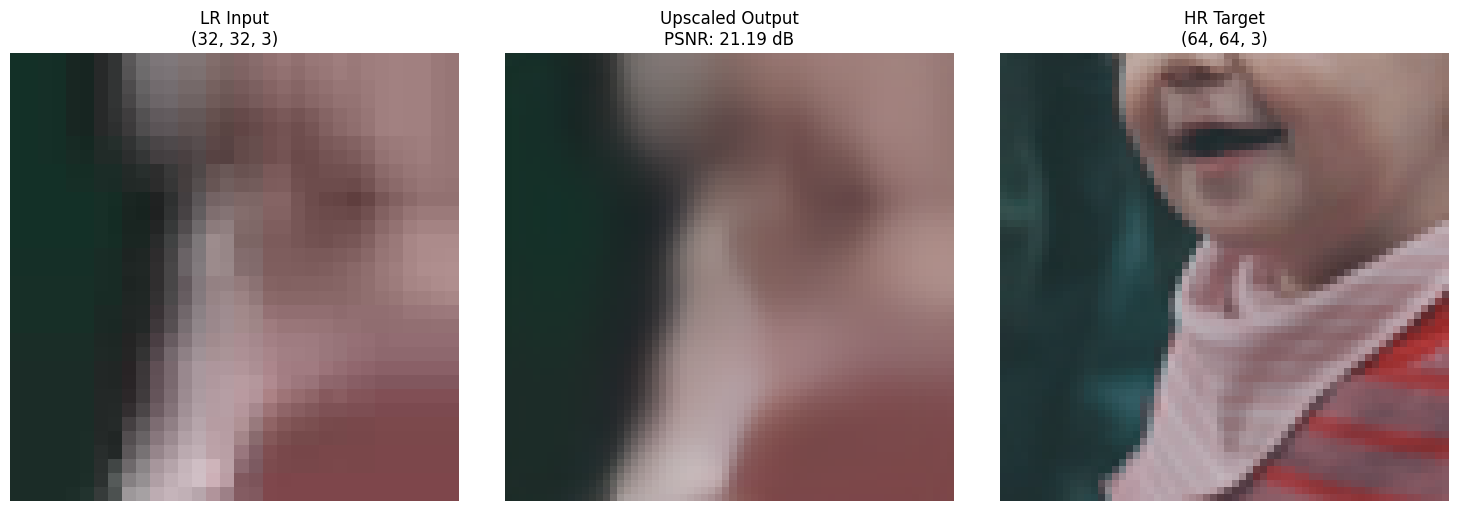

In [21]:
visualize_dataset_element(val_ds, index=636, model=dummy_model)
visualize_dataset_element(val_ds, index=636, model=model)